# Smart Cargo E-Bike, Part 4 — 3-D Multibody Dynamics & Co-Simulation (MuJoCo)

**Reading time ~30 min · runtime ~2 min on CPU (MuJoCo steps in real-time; one
~50 s Jaxonomy planar run for the comparison).**

The [Part 1](ebike_part1_smart_cargo.ipynb) vehicle is a **bird's-eye 3-DOF
planar** model: longitudinal, lateral, and yaw motion of a rigid body on a flat
plane. It is perfect for energy, range, and control-loop design — but it has, by
construction, **no vertical motion, no pitch, no suspension, and no ground
contact**. It cannot tell you whether a heavily-loaded cargo bike squats,
pitches under braking, or bottoms out its suspension over a kerb.

For those questions you need **3-D multibody dynamics**. Here we build the
companion the planar model is blind to: a MuJoCo cargo e-bike with real
tyre-ground contact and suspension, driven by the *same* assist-torque law, and
we run it **in co-simulation** — Jaxonomy-style controller, MuJoCo plant.

> **Prerequisites.** Part 1. Requires `mujoco` (`pip install mujoco`). We reuse
> the co-sim from `ebike_mujoco_cosim.py`.

## 1. What multibody dynamics *is* (and how it differs from 0-D/1-D)

A multibody model tracks a set of rigid bodies linked by **joints**. Its state
is a vector of **generalized coordinates** $\mathbf q$ (joint angles/positions)
and velocities $\dot{\mathbf q}$, and it obeys the equations of motion
$$ \mathbf M(\mathbf q)\,\ddot{\mathbf q} + \mathbf c(\mathbf q,\dot{\mathbf q}) = \boldsymbol\tau + \mathbf J^{\!\top}\boldsymbol\lambda, \tag{1}$$
where $\mathbf M$ is the (configuration-dependent) mass matrix, $\mathbf c$
gathers Coriolis/centrifugal/gravity terms, $\boldsymbol\tau$ are applied
joint torques, and $\mathbf J^{\!\top}\boldsymbol\lambda$ are constraint forces
(contacts, joint limits). Dimensional sanity: each row of (1) is a
Newton–Euler balance — $[\mathbf M \ddot q]=$ N·m for a rotational DOF.

**Contact & friction** are the hard part. MuJoCo (Todorov 2012) uses a
*soft, convex* contact model: instead of hard complementarity ("either no
penetration or no force"), it solves a well-posed convex optimization each step
for contact impulses, which makes contact-rich simulation fast and
differentiable-friendly at the cost of a little compliance.

**How this differs from the acausal 0-D/1-D world of Parts 1–3.** Those models
are *lumped*: a scalar per state, algebraic/ODE/DAE couplings, no geometry.
Multibody adds **kinematic geometry** — where bodies are in 3-D space, how they
rotate, how they touch the ground. That geometry is exactly what produces pitch,
weight transfer, and suspension response. It is complementary, not competing:
the lumped model owns the powertrain/energy; the multibody model owns the
chassis motion.

## 2. Setup and the co-simulation contract

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage

sys.path.append(os.path.abspath("."))
import ebike_mujoco_cosim as mj
from ebike_mujoco_cosim import MEDIA, run, wheel_drive_torque

print("MuJoCo scene:", os.path.basename(mj.XML))

MuJoCo scene: ebike_mujoco.xml


**The control loop — named honestly.** Each control tick, the *controller*
reads the model's **named sensors** (the same wiring harness a
hardware-in-the-loop controller would be limited to — not raw simulator state)
and computes a rear-wheel drive torque from a quantitative mirror of Part 1's
assist law; the *plant* (MuJoCo) integrates the full 3-D dynamics with contact
and suspension. This is **controller-in-the-loop simulation**: one solver, with
the controller evaluated inside its stepping loop at 500 Hz. It is *not*
co-simulation in the technical sense — that word means two solvers with their
own integrators exchanging boundary variables at a coupling rate, with all the
extrapolation-and-drift craft that entails (Part 5 §7 taxonomizes those
patterns; an earlier version of this notebook used the word loosely). The
sensor/actuator interface is still the HIL-shaped seam: swap the plant for
hardware and the controller code does not change.

**The drive law, quantitatively tied to Part 1:** motor assist = 12 N·m at the
motor shaft × the 2.5:1 chain = 30 N·m at the wheel, faded over the same
2 km/h band to the 25 km/h cutoff; rider = 8 N·m at the wheel ≈ Part 1's
15–18 N·m crank torque halved by the crank:wheel ratio (~110 W at cruise — a
plausible human, where an earlier version pedalled a perpetual 600 W).
Masses match too: 180 kg total on both sides of every comparison below.

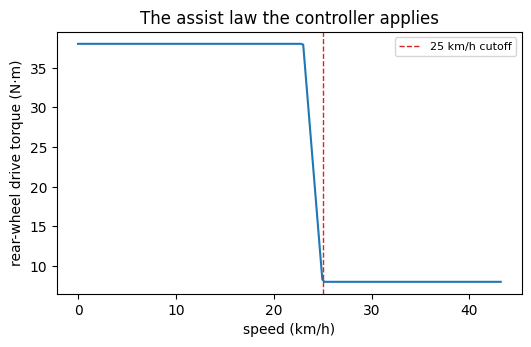

In [2]:
v = np.linspace(0, 12, 200)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(v * 3.6, [wheel_drive_torque(vi) for vi in v], color="tab:blue")
ax.axvline(25, color="tab:red", ls="--", lw=1, label="25 km/h cutoff")
ax.set(xlabel="speed (km/h)", ylabel="rear-wheel drive torque (N·m)",
       title="The assist law the controller applies"); ax.legend(fontsize=8)
plt.show()

*Figure 1: the wheel-torque law — a constant ~8 N·m rider contribution plus a
30 N·m motor assist that fades linearly from 23 km/h and is gone at the legal
25 km/h. Both numbers are Part 1's drivetrain reflected to the wheel, so the
planar and 3-D models are driven identically by construction.*

## 3. The ride — what the 3-D model resolves that the planar one cannot

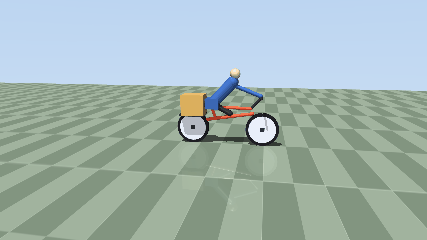

In [3]:
IPyImage(filename=os.path.join(MEDIA, "ebike_mujoco_cosim.gif"))

*Animation: the cargo bike accelerates from rest, squats slightly on its rear
suspension under drive torque, works its suspension over a 3 m speed hump,
picks up speed down the 6% descent until the assist cuts at 25 km/h, and
carries its momentum into the 6% climb. Roll and yaw are suppressed by
construction (a sagittal-plane base: longitudinal slide + vertical heave +
pitch hinge) so the run stays upright without solving bicycle self-balance —
the point here is the **sagittal** physics, not lateral stability. All pitch
values in this notebook are **nose-up positive** (the raw MJCF hinge is
nose-down positive; the logging layer negates it exactly once).*

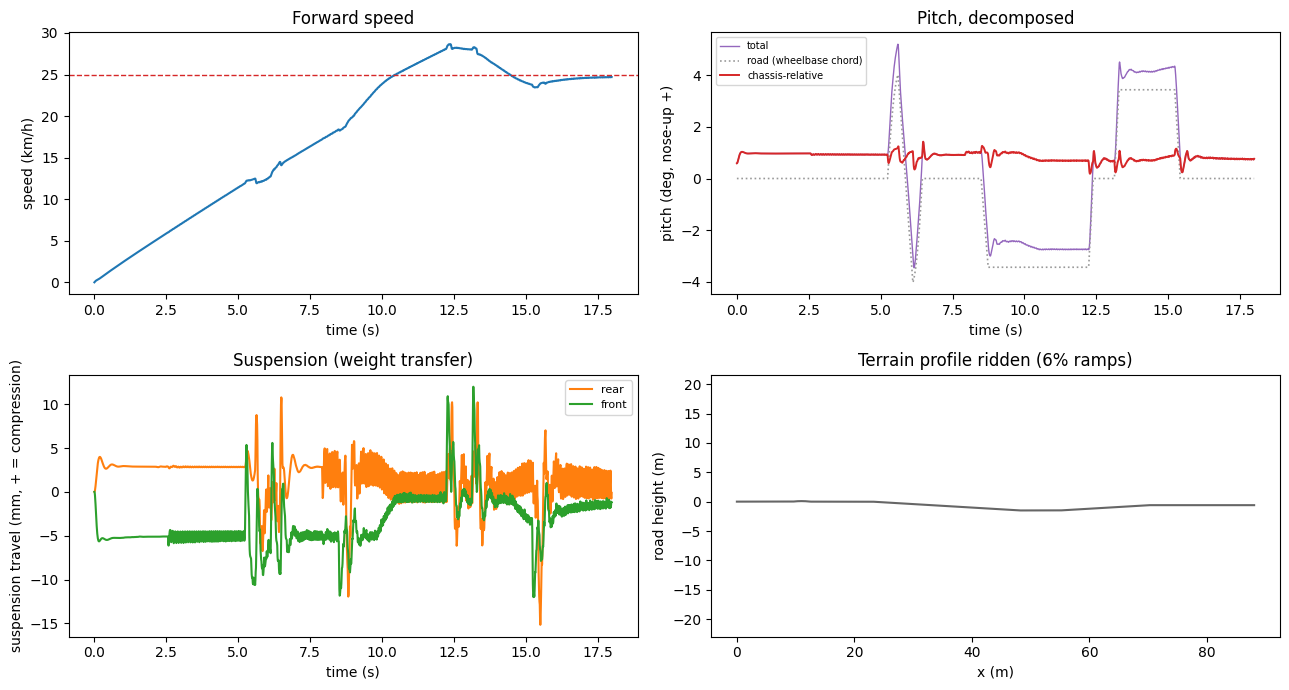

pitch (deg, nose-up +): total [-3.5, +5.2] = road [-4.0, +4.0] + chassis-relative [+0.2, +1.4]


In [4]:
tr = run(t_end=18.0)                     # a live run (~0.5 s of wall time)
t = tr["t"]
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
ax[0, 0].plot(t, tr["speed_mps"] * 3.6, color="tab:blue"); ax[0, 0].axhline(25, color="tab:red", ls="--", lw=1)
ax[0, 0].set(xlabel="time (s)", ylabel="speed (km/h)", title="Forward speed")
ax[0, 1].plot(t, np.degrees(tr["pitch_rad"]), color="tab:purple", lw=1.0, label="total")
ax[0, 1].plot(t, np.degrees(tr["road_pitch_rad"]), color="0.6", ls=":", lw=1.2, label="road (wheelbase chord)")
ax[0, 1].plot(t, np.degrees(tr["pitch_rel_rad"]), color="tab:red", lw=1.4, label="chassis-relative")
ax[0, 1].set(xlabel="time (s)", ylabel="pitch (deg, nose-up +)", title="Pitch, decomposed"); ax[0, 1].legend(fontsize=7)
ax[1, 0].plot(t, tr["susp_travel_m"] * 1000, color="tab:orange", label="rear")
ax[1, 0].plot(t, tr["front_travel_m"] * 1000, color="tab:green", label="front")
ax[1, 0].set(xlabel="time (s)", ylabel="suspension travel (mm, + = compression)",
             title="Suspension (weight transfer)"); ax[1, 0].legend(fontsize=8)
ax[1, 1].plot(tr["x_m"], tr["road_h_m"], color="0.4")
ax[1, 1].set(xlabel="x (m)", ylabel="road height (m)", title="Terrain profile ridden (6% ramps)"); ax[1, 1].axis("equal")
fig.tight_layout(); plt.show()

print(f"pitch (deg, nose-up +): total [{np.degrees(tr['pitch_rad']).min():+.1f}, "
      f"{np.degrees(tr['pitch_rad']).max():+.1f}] = road "
      f"[{np.degrees(tr['road_pitch_rad']).min():+.1f}, {np.degrees(tr['road_pitch_rad']).max():+.1f}]"
      f" + chassis-relative [{np.degrees(tr['pitch_rel_rad']).min():+.1f}, "
      f"{np.degrees(tr['pitch_rel_rad']).max():+.1f}]")


*Figure 2: a single run, with the pitch panel telling the story an earlier
version of this notebook got wrong. Total chassis pitch swings several degrees
— but most of that is the **road**: on the 6% ramps any vehicle, planar models
included, is geometrically pitched exactly $\arctan(0.06) = 3.43°$, and the
wheelbase chord over the speed hump reaches ±4.0°, which is where the printed
road-pitch extremes come from. Either way it is *terrain*, and the planar model
already knows the grade — it is an input, not a discovery. The multibody *content* is the red curve: the
chassis-relative pitch — drive squat of ~1° plus the suspension's response
over the hump — which is honestly small. That, plus the front/rear suspension
travel (the rear carries the cargo bias) and dynamic weight transfer over the
hump, is what only this model resolves. Headline the red curve, not the
purple one.*

## 4. Phase portraits & a 3-D view

Multibody state lives in phase space. Two views the planar model has no
coordinates for: the **pitch phase portrait** (angle vs rate — a stable focus
spiralling to the loaded equilibrium) and the **suspension force–deflection
loop** (hysteresis = energy dissipated per bump cycle by the damper).

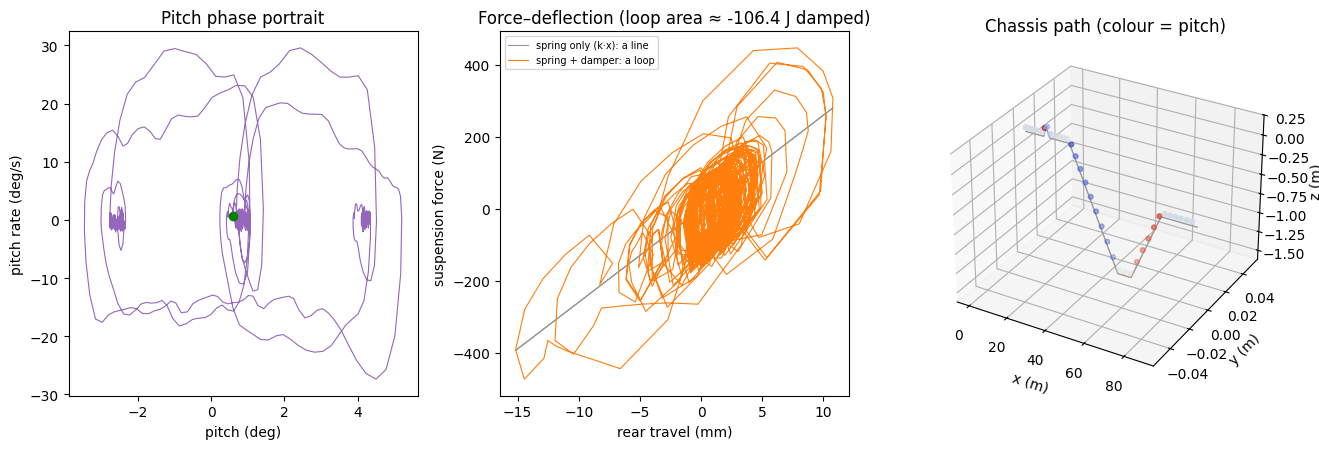

In [5]:
pitch = np.degrees(tr["pitch_rad"]); pitch_rate = np.gradient(pitch, t)
rear_m = tr["susp_travel_m"]
# The MJCF's actual rear suspension constants (see media/ebike_mujoco.xml):
K_SUSP = 26000.0   # N/m   (spring)
C_SUSP = 850.0     # N·s/m (damper)
rear_rate = np.gradient(rear_m, t)
F_spring = K_SUSP * rear_m
F_total = F_spring + C_SUSP * rear_rate
# enclosed loop area = damper-dissipated energy over the traversal
E_loop = float(-np.trapezoid(F_total, rear_m))

fig = plt.figure(figsize=(13, 4.6))
axa = fig.add_subplot(1, 3, 1)
axa.plot(pitch, pitch_rate, color="tab:purple", lw=0.8); axa.plot(pitch[0], pitch_rate[0], "go")
axa.set(xlabel="pitch (deg)", ylabel="pitch rate (deg/s)", title="Pitch phase portrait")
axb = fig.add_subplot(1, 3, 2)
axb.plot(rear_m * 1000, F_spring, color="0.6", lw=0.8, label="spring only (k·x): a line")
axb.plot(rear_m * 1000, F_total, color="tab:orange", lw=0.8, label="spring + damper: a loop")
axb.set(xlabel="rear travel (mm)", ylabel="suspension force (N)",
        title=f"Force–deflection (loop area ≈ {E_loop:.1f} J damped)")
axb.legend(fontsize=7)
axc = fig.add_subplot(1, 3, 3, projection="3d")
axc.plot(tr["x_m"], np.zeros_like(t), tr["road_h_m"], color="0.6", lw=1, label="track")
axc.scatter(tr["x_m"][::40], np.zeros_like(t)[::40], tr["road_h_m"][::40] + 0.05,
            c=pitch[::40], cmap="coolwarm", s=12)
axc.set(xlabel="x (m)", ylabel="y (m)", zlabel="z (m)", title="Chassis path (colour = pitch)")
fig.tight_layout(); plt.show()


*Figure 3: (left) pitch spirals into its loaded equilibrium — a damped
oscillator seen in phase space. (middle) The force–deflection plot, done
right: the spring term $kx$ alone is by definition a straight line through the
origin — **it can never enclose area**, and a plot of $kx$ against $x$ dressed
up as a "hysteresis loop" is a tautology (an earlier version of this notebook
committed exactly that, with an "illustrative" spring rate 73% stiffer than
the model's). Add the damper term $c\dot x$ and the trajectory encloses a
loop whose area is genuinely the energy the damper dissipated — computed here
from the model's own $k$ = 26 kN/m and $c$ = 850 N·s/m. (right) The path over
the terrain, coloured by pitch.*

## 5. A parametric study only 3-D can do: weight transfer vs cargo

Load a cargo bike and the chassis *sits down* on its suspension and pitches
differently — first-order design information (suspension travel budget, ground
clearance, handling) that a lumped model simply does not carry. We sweep the
rear payload and read the 3-D response.

  NOTE cargo=90 kg: rear suspension is AT its 50 mm travel stop (50.9 mm) -- the curve flattens because the joint ran out, not because the physics did


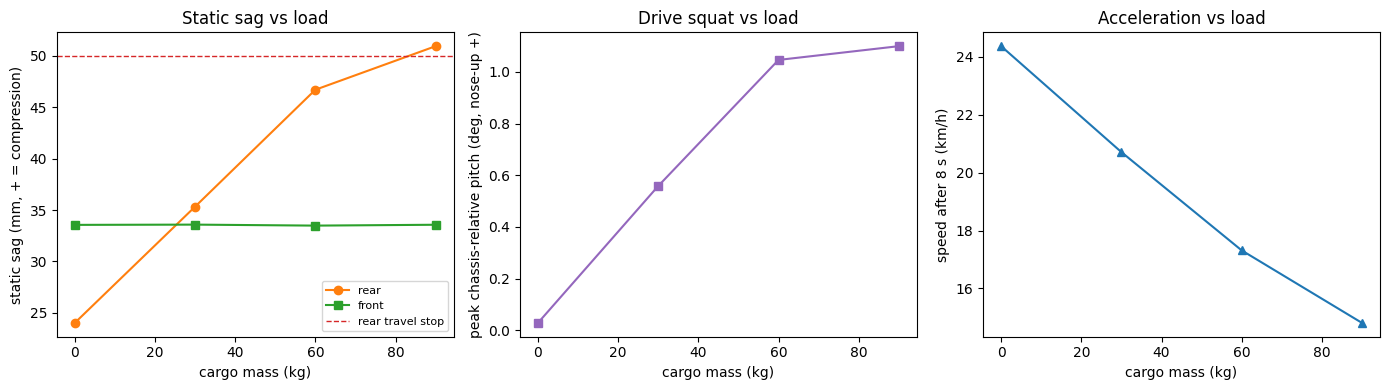

 cargo kg  rear sag mm  front sag mm  squat deg  v@8s kmh
        0         24.0          33.6       0.03     24.37
       30         35.3          33.6       0.56     20.71
       60         46.7          33.5       1.05     17.31
       90         50.9          33.6       1.10     14.81

front sag varies by only 0.10 mm across a 90 kg
payload swing: the rack sits essentially over the rear axle, so the load
path is rear-only -- which is exactly the geometric fact a lumped model
cannot represent, and the reason cargo bikes size their rear spring first.


In [6]:
# Sweep the payload ON FLAT GROUND: load effects show up clean, not confounded
# with how far into the terrain each run gets in a fixed window (which is what
# a terrain sweep actually measures).
#
# Read STATIC SAG from the absolute settled suspension position, not from
# `susp_travel_m`. Travel is measured relative to each run's OWN rest pose, so
# it cancels static sag by construction -- a payload study that only reads
# travel measures nothing about how far the bike sits down. (Fixing exactly
# that bug is why `rear_static_m` exists.)
cargos = [0.0, 30.0, 60.0, 90.0]
REAR_RANGE_MM = 50.0     # MJCF rear_susp joint range: -0.10 .. +0.05 m
rows = []
for m in cargos:
    r = run(t_end=8.0, cargo_mass=m, terrain=False)
    v = r["speed_mps"] * 3.6
    rear_sag = float(r["rear_static_m"]) * 1000
    front_sag = float(r["front_static_m"]) * 1000
    rows.append((m, rear_sag, front_sag, np.degrees(r["pitch_rel_rad"]).max(), v[-1]))
    if rear_sag >= 0.98 * REAR_RANGE_MM:
        print(f"  NOTE cargo={m:.0f} kg: rear suspension is AT its {REAR_RANGE_MM:.0f} mm "
              f"travel stop ({rear_sag:.1f} mm) -- the curve flattens because the "
              f"joint ran out, not because the physics did")
rows = np.array(rows)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(rows[:, 0], rows[:, 1], "o-", color="tab:orange", label="rear")
ax[0].plot(rows[:, 0], rows[:, 2], "s-", color="tab:green", label="front")
ax[0].axhline(REAR_RANGE_MM, color="tab:red", ls="--", lw=1, label="rear travel stop")
ax[0].set(xlabel="cargo mass (kg)", ylabel="static sag (mm, + = compression)",
          title="Static sag vs load"); ax[0].legend(fontsize=8)
ax[1].plot(rows[:, 0], rows[:, 3], "s-", color="tab:purple")
ax[1].set(xlabel="cargo mass (kg)", ylabel="peak chassis-relative pitch (deg, nose-up +)",
          title="Drive squat vs load")
ax[2].plot(rows[:, 0], rows[:, 4], "^-", color="tab:blue")
ax[2].set(xlabel="cargo mass (kg)", ylabel="speed after 8 s (km/h)", title="Acceleration vs load")
fig.tight_layout(); plt.show()

print(f"{'cargo kg':>9} {'rear sag mm':>12} {'front sag mm':>13} {'squat deg':>10} {'v@8s kmh':>9}")
for m, rs, fs, p, vf in rows:
    print(f"{m:9.0f} {rs:12.1f} {fs:13.1f} {p:10.2f} {vf:9.2f}")

# the front axle carries (almost) none of a rear-rack payload -- check it
print(f"\nfront sag varies by only {np.ptp(rows[:,2]):.2f} mm across a {rows[-1,0]:.0f} kg")
print("payload swing: the rack sits essentially over the rear axle, so the load")
print("path is rear-only -- which is exactly the geometric fact a lumped model")
print("cannot represent, and the reason cargo bikes size their rear spring first.")


*Figure 4: the flat-ground payload sweep, read from **absolute** settled
suspension positions. The rear spring takes essentially all of the payload
(rear sag climbs steeply; front sag is flat to a few hundredths of a
millimetre) because the rack sits over the rear axle — a geometric load path a
lumped model has no way to express. Drive squat grows with load, and the launch
slows. Two honesty notes the code enforces: the sweep runs on **flat ground**,
because a fixed-time sweep over *terrain* mostly measures how far into the
hills each run got (a windowing confound, not a load effect); and at the
heaviest payload the rear joint reaches its **+50 mm travel stop**, so the sag
curve flattens for a mechanical reason the cell prints rather than letting the
plot imply diminishing physical sensitivity. This — ride height, travel budget,
launch feel — is the class of question that justifies a multibody model.*


## 6. Consistency with the planar model

The 3-D and planar models should agree *in the plane* they share (longitudinal
speed) and differ only out of it. We run the Part-1 planar model on flat ground
with the same assist policy and overlay.

20:26:13.709 - [jaxonomy][INFO]: max_major_steps=17998 based on smallest discrete period=0.002


20:26:13.710 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=17998, ode_solver_method=auto, rtol=0.0005, atol=5e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), BDFSolver(system=Diagram(ebike_system, 20 nodes), rtol=0.0005, atol=5e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


masses: planar 180 kg, MuJoCo 180 kg
flat-road speed deviation: RMS 0.82 km/h, max 1.24 km/h over 18 s
(what remains is genuine modelling difference: drivetrain compliance +
 motor dynamics in the planar model vs direct wheel torque + contact here)


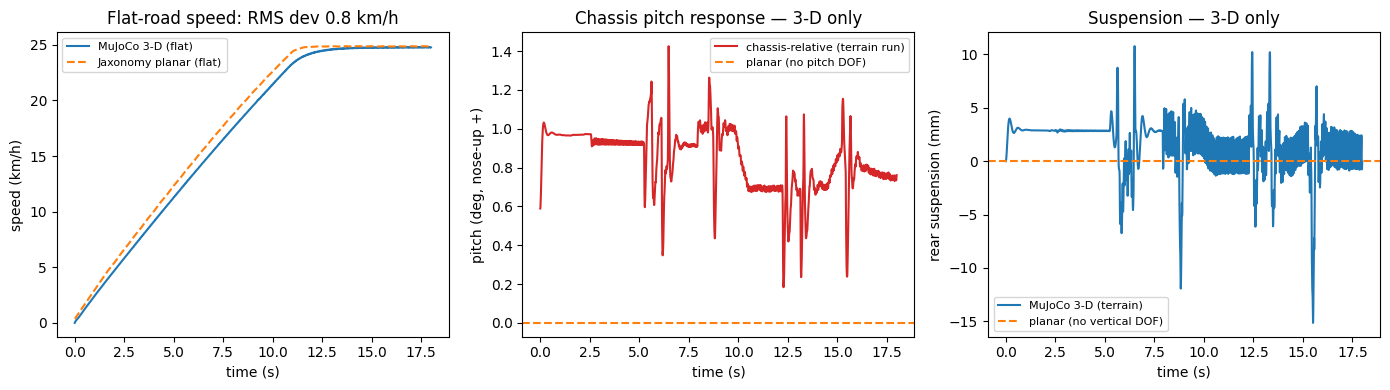

In [7]:
import warnings
import jaxonomy
from jaxonomy.simulation import SimulatorOptions
from ebike_hybrid_simulation import make_ebike_diagram, EbikeConfig

# like-for-like: BOTH models on flat ground, same drive law, same 180 kg
tr_flat = run(t_end=18.0, terrain=False)
_cfg = EbikeConfig(grade_hold=0.0, tf=18.0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    _diag = make_ebike_diagram(_cfg)
    _opts = SimulatorOptions(enable_autodiff=False, rtol=5e-4, atol=5e-6, buffer_length=260000)
    _res = jaxonomy.simulate(_diag, _diag.create_context(), (0.0, 18.0), options=_opts,
                             recorded_signals={p.name: p for p in _diag.output_ports if p.name == "speed"})
t_pl = np.asarray(_res.time).squeeze(); v_pl = np.asarray(_res.outputs["speed"]).squeeze() * 3.6

v_mj = tr_flat["speed_mps"] * 3.6
dev = v_mj - np.interp(tr_flat["t"], t_pl, v_pl)
rms_kmh, max_kmh = float(np.sqrt(np.mean(dev**2))), float(np.max(np.abs(dev)))
print(f"masses: planar {_cfg.m_total:.0f} kg, MuJoCo {float(tr_flat['total_mass_kg']):.0f} kg")
print(f"flat-road speed deviation: RMS {rms_kmh:.2f} km/h, max {max_kmh:.2f} km/h over 18 s")
print("(what remains is genuine modelling difference: drivetrain compliance +")
print(" motor dynamics in the planar model vs direct wheel torque + contact here)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(tr_flat["t"], v_mj, color="tab:blue", label="MuJoCo 3-D (flat)")
ax[0].plot(t_pl, v_pl, "--", color="tab:orange", label="Jaxonomy planar (flat)")
ax[0].set(xlabel="time (s)", ylabel="speed (km/h)",
          title=f"Flat-road speed: RMS dev {rms_kmh:.1f} km/h"); ax[0].legend(fontsize=8)
ax[1].plot(tr["t"], np.degrees(tr["pitch_rel_rad"]), color="tab:red", label="chassis-relative (terrain run)")
ax[1].axhline(0, color="tab:orange", ls="--", label="planar (no pitch DOF)")
ax[1].set(xlabel="time (s)", ylabel="pitch (deg, nose-up +)", title="Chassis pitch response — 3-D only"); ax[1].legend(fontsize=8)
ax[2].plot(tr["t"], tr["susp_travel_m"] * 1000, color="tab:blue", label="MuJoCo 3-D (terrain)")
ax[2].axhline(0, color="tab:orange", ls="--", label="planar (no vertical DOF)")
ax[2].set(xlabel="time (s)", ylabel="rear suspension (mm)", title="Suspension — 3-D only"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()


*Figure 5: the comparison, split the honest way. Left: **both models on flat
ground with identical mass, drive law, CdA and rolling resistance** — the speed
traces agree to an RMS printed above (not asserted), and what remains is real
modelling difference, quantified. (An earlier version compared a planar
flat-ground run against the 3-D model on hilly terrain and called the
similarity "consistent" — two different experiments that happened to cross.)
Middle/right: the 3-D-only signals from the terrain run. Agreement-in-plane is
the validation; the decomposed out-of-plane response is the value.*

## 7. When to reach for multibody — and its limits

**Use multibody when the question is geometric/mechanical:** ride & handling,
suspension sizing, weight transfer and stability, durability load cases,
contact-rich manoeuvres (kerbs, potholes), and — with **MJX** (JAX-native
MuJoCo) — differentiable, GPU-batched rollouts for policy optimization and
sim-to-real RL.

**Stay lumped when the question is energetic/control:** range, efficiency,
thermal, controller tuning — Parts 1–3 answer those far more cheaply.

**Limitations.** (i) *Parameter identification* — inertias, contact stiffness,
and damping are hard to measure; garbage-in. (ii) *Contact fidelity* — MuJoCo's
soft-convex contact is fast but approximate; true stress/strain needs FEA. And
be precise about a fidelity **inversion** in this very notebook: the planar
model's tyre is a Magic Formula (slip-curve) model, while this "higher-fidelity"
3-D plant rolls a rigid cylinder in a Coulomb friction cone — no slip stiffness,
no relaxation length. For *longitudinal traction* questions the planar model's
tyre is the better one; the 3-D model's advantage is geometry, suspension and
contact kinematics, not tyre physics.
(iii) *Rigid bodies* — frame flex, tyre carcass deformation are not captured
without flexible-body extensions. (iv) *Self-balancing* — a free bicycle is
famously hard; we sidestepped it by constraining roll, which is fine for
sagittal studies but not for handling/stability work.

**Alternatives.** Simscape Multibody, Drake, Bullet/PyBullet, Isaac Sim;
analytical bicycle models (Whipple/Carvallo) for stability; full FEA for
structural loads.

## 8. Failure modes

- **Contact instability** — too-stiff contacts or too-large a timestep make the
  wheels chatter or tunnel through the road; MuJoCo needs `mass and inertia >
  mjMINVAL` on every moving body (no massless intermediate links).
- **Terrain representation can silently dominate the energy budget.** This
  model originally rolled on a triangulated heightfield; a coast-down test
  (Exercise 6) measured its effective rolling resistance at Crr ≈ 0.047 —
  **six times** the Crr = 0.008 the contact was configured for — because the
  wheel touches several facets whose normals disagree by a few degrees and the
  resulting micro-slip dissipates continuously. Finer facets made it *worse*,
  and no solver option fixed it. The road is therefore built from flat box
  segments (locally exact planes: measured Crr 0.0087 = rolling 0.008 +
  bearing ~0.001) with a capsule speed hump. Moral: validate the *loss budget*
  of a contact model with a designed experiment before trusting any energy or
  speed number that rides on it.
- **Unphysical parameters** — a bogus contact stiffness or inertia gives
  plausible-looking but wrong dynamics; always sanity-check against a known
  case (the printed energy budget in the runner script is that gate here).
- **Reading too much into a constrained model** — we suppressed roll/yaw, so
  nothing here speaks to lateral stability; don't over-interpret.
- **Aero without a moment** — drag is applied at the frame's centre of mass, so
  it carries no pitch moment; high-speed aero squat is absent by construction.


## 9. Exercises

1. **(code)** Raise the speed-hump height in `road_height` and watch the
   suspension force–deflection loop grow. How does the damped energy (the loop
   area printed in Figure 3) scale with hump height?
2. **(code)** Extend the cargo sweep to also record *braking* pitch (add a
   deceleration phase). Does the load shift forward as expected, and does the
   front suspension's travel budget survive a 90 kg payload?
3. **(concept)** The bike model constrains roll. What would you need to add to
   study countersteering and self-stability, and why is that hard?
4. **(concept)** Sketch a **hardware-in-the-loop** version of this loop: which
   signals cross the boundary (hint: exactly the named sensors and the actuator
   command — which is why the code reads only those), and what real-time
   constraints appear?
5. **(code)** Narrow the speed hump back to a 1 m parking-lot bump
   (`BUMP_RADIUS = 0.15`) and rerun. At what speed does the driven wheel leave
   the ground, and what happens to the drive torque while it is airborne?
   (This regime — brief flight + wheelspin under full assist — is real physics
   the 3 m hump deliberately avoids for the teaching run.)
6. **(code — the loss audit, replayed)** Reproduce the coast-down experiment
   from the failure-modes list: no drive, no aero, launch at 25 km/h on flat
   ground, fit the deceleration, and convert to an effective Crr. Then swap the
   box road for a heightfield version and measure again. Which number would
   you have believed without the experiment?
7. **(open-ended)** Port the plant to **MJX** and use `jax.grad` through a
   batched rollout to tune a suspension parameter for minimum peak chassis
   acceleration over the hump.


## Key takeaways

- Multibody dynamics adds the **3-D kinematic geometry** (pitch, heave,
  contact, suspension) that lumped 0-D/1-D models structurally omit.
- **Co-simulation** cleanly splits controller (Jaxonomy) from plant (MuJoCo)
  over a sensor/actuator interface — the same interface generalizes to HIL.
- The two models **agree in-plane and diverge out-of-plane**: use that to
  validate the reduced model and to know what it cannot tell you.
- Reach for multibody on **geometric/mechanical** questions (ride, handling,
  loads); stay lumped for **energetic/control** ones. MJX makes the 3-D plant
  differentiable for optimization.

**Next:** [Part 5](ebike_part5_openfoam_cfd.ipynb) — CFD & conjugate heat
transfer with OpenFOAM.

## References
- R. Featherstone, *Rigid Body Dynamics Algorithms*, Springer 2008.
- E. Todorov, T. Erez, Y. Tassa, *MuJoCo: A physics engine for model-based control*, IROS 2012.
- MuJoCo MJX documentation (JAX-native MuJoCo).